In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# Generate synthetic dataset

In [3]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.02

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Split the data into training and test sets

In [5]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)


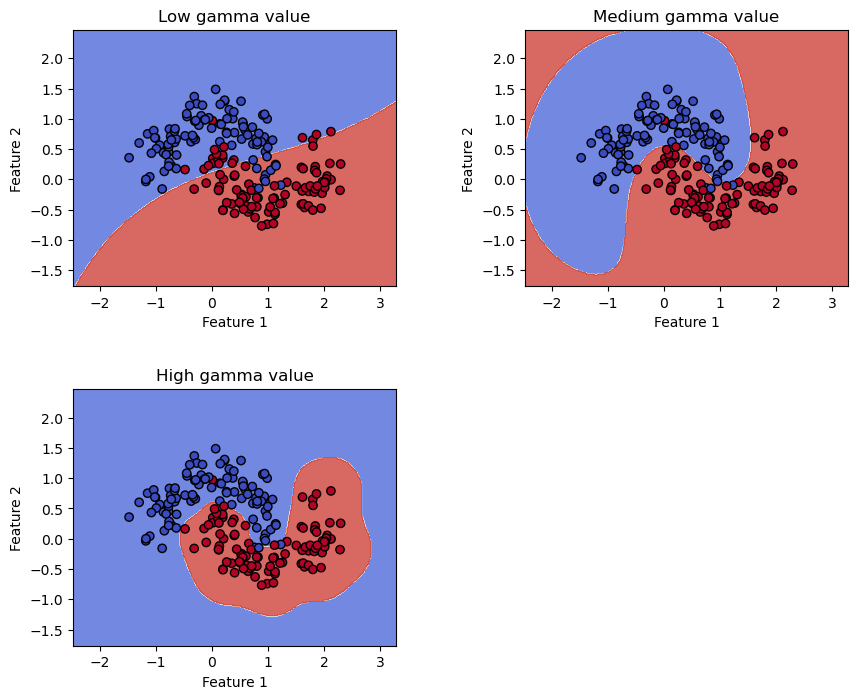

In [6]:





# Title for the plots
titles = ['Low gamma value', 'Medium gamma value', 'High gamma value']

# Different gamma values
gamma_values = [0.1, 1, 10]

# SVM regularization parameter
C = 1.0

plt.figure(figsize=(10, 8))

for i, gamma in enumerate(gamma_values):

    # Fit the model
    clf = svm.SVC(kernel='rbf', gamma=gamma, C=C)
    clf.fit(X_train, y_train)

    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(titles[i])

plt.show()